# Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Edutech

- **Nama**: [Andy Yulianto]
- **Email**: [rinovannet@gmail.com]
- **Id Dicoding**: [andyid]

## Persiapan

In [1]:
### Install Dependencies

In [2]:
import subprocess
import sys

def install(package):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', package])

packages = [
    'pandas', 'numpy', 'matplotlib', 'seaborn',
    'scikit-learn==1.2.2', 'joblib', 'sqlalchemy', 'psycopg2-binary'
]

for pkg in packages:
    try:
        __import__(pkg.replace('-', '_').split('==')[0])
        print(f"✅ {pkg} sudah terinstall")
    except ImportError:
        print(f"Installing {pkg}...")
        install(pkg)
        print(f"  ✅ {pkg} installed")

print("\n✅ Semua dependencies siap!")

✅ pandas sudah terinstall
✅ numpy sudah terinstall
✅ matplotlib sudah terinstall
✅ seaborn sudah terinstall
Installing scikit-learn==1.2.2...
  ✅ scikit-learn==1.2.2 installed
✅ joblib sudah terinstall
✅ sqlalchemy sudah terinstall
Installing psycopg2-binary...
  ✅ psycopg2-binary installed

✅ Semua dependencies siap!


### Menyiapkan library yang dibutuhkan

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sqlalchemy import create_engine, text
import joblib
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
sns.set_palette('husl')
print("✅ Semua library berhasil diimport!")

✅ Semua library berhasil diimport!


### Menyiapkan data yang akan diguankan

## Data Understanding

In [4]:
df = pd.read_csv('https://raw.githubusercontent.com/dicodingacademy/dicoding_dataset/main/students_performance/data.csv', sep=';')
print(f"Dataset shape: {df.shape}")
print(f"Jumlah baris: {df.shape[0]}")
print(f"Jumlah kolom: {df.shape[1]}")
print(f"\nKolom: {list(df.columns)}")
df.head()

Dataset shape: (4424, 37)
Jumlah baris: 4424
Jumlah kolom: 37

Kolom: ['Marital_status', 'Application_mode', 'Application_order', 'Course', 'Daytime_evening_attendance', 'Previous_qualification', 'Previous_qualification_grade', 'Nacionality', 'Mothers_qualification', 'Fathers_qualification', 'Mothers_occupation', 'Fathers_occupation', 'Admission_grade', 'Displaced', 'Educational_special_needs', 'Debtor', 'Tuition_fees_up_to_date', 'Gender', 'Scholarship_holder', 'Age_at_enrollment', 'International', 'Curricular_units_1st_sem_credited', 'Curricular_units_1st_sem_enrolled', 'Curricular_units_1st_sem_evaluations', 'Curricular_units_1st_sem_approved', 'Curricular_units_1st_sem_grade', 'Curricular_units_1st_sem_without_evaluations', 'Curricular_units_2nd_sem_credited', 'Curricular_units_2nd_sem_enrolled', 'Curricular_units_2nd_sem_evaluations', 'Curricular_units_2nd_sem_approved', 'Curricular_units_2nd_sem_grade', 'Curricular_units_2nd_sem_without_evaluations', 'Unemployment_rate', 'Inflati

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [5]:
print("=" * 60)
print("INFORMASI DATASET")
print("=" * 60)
print(f"Jumlah baris: {df.shape[0]}")
print(f"Jumlah kolom: {df.shape[1]}")
print(f"\nMissing values: {df.isnull().sum().sum()}")
print(f"\nTipe data:")
print(df.dtypes.value_counts())
df.describe()

INFORMASI DATASET
Jumlah baris: 4424
Jumlah kolom: 37

Missing values: 0

Tipe data:
int64      29
float64     7
object      1
Name: count, dtype: int64


,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_1st_sem_without_evaluations,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.178571,18.669078,1.727848,8856.642631,0.890823,4.577758,132.613314,1.873192,19.561935,22.275316,...,0.137658,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969
std,0.605747,17.484682,1.313793,2063.566416,0.311897,10.216592,13.188332,6.914514,15.603186,15.343108,...,0.690880,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935
min,1.000000,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,1.000000,1.000000,1.000000,9085.000000,1.000000,1.000000,125.000000,1.000000,2.000000,3.000000,...,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000
50%,1.000000,17.000000,1.000000,9238.000000,1.000000,1.000000,133.100000,1.000000,19.000000,19.000000,...,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000
75%,1.000000,39.000000,2.000000,9556.000000,1.000000,1.000000,140.000000,1.000000,37.000000,37.000000,...,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000
max,6.000000,57.000000,9.000000,9991.000000,1.000000,43.000000,190.000000,109.000000,44.000000,44.000000,...,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000


## Data Preparation / Preprocessing

Distribusi Status Mahasiswa (Seluruh Data):
Status
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

Persentase:
Status
Graduate    49.93
Dropout     32.12
Enrolled    17.95
Name: count, dtype: float64


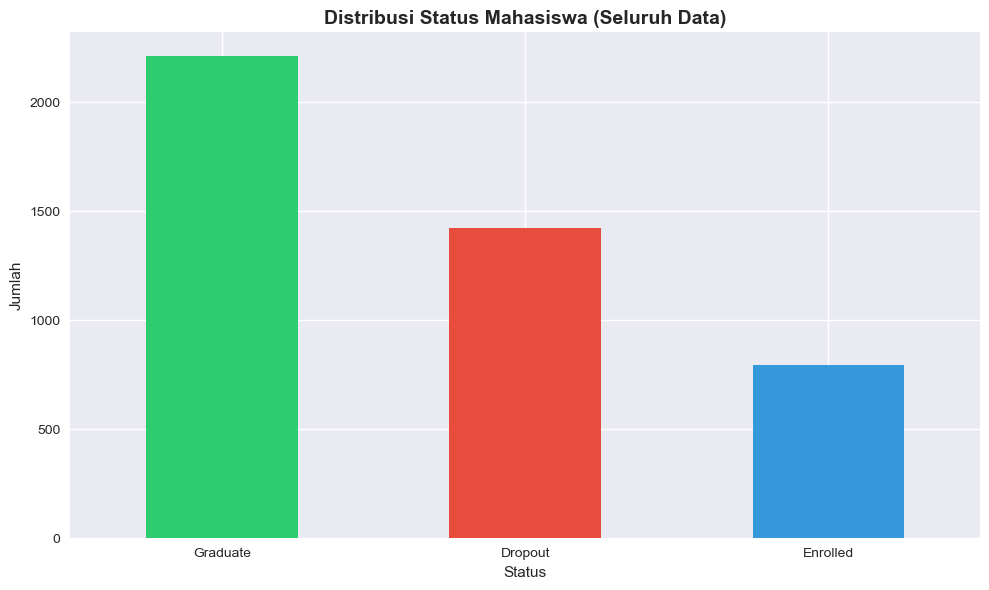


Insight:
- Total data: 4424 mahasiswa
- Dropout: 1421 (32.1%)
- Graduate: 2209 (49.9%)
- Enrolled: 794 (17.9%)

Data Enrolled akan digunakan untuk inferensi, bukan training.


In [6]:
status_counts = df['Status'].value_counts()
print("Distribusi Status Mahasiswa (Seluruh Data):")
print(status_counts)
print(f"\nPersentase:")
print((status_counts / len(df) * 100).round(2))

plt.figure(figsize=(10, 6))
colors = {'Graduate': '#2ecc71', 'Dropout': '#e74c3c', 'Enrolled': '#3498db'}
status_counts.plot(kind='bar', color=[colors[x] for x in status_counts.index])
plt.title('Distribusi Status Mahasiswa (Seluruh Data)', fontsize=14, fontweight='bold')
plt.xlabel('Status')
plt.ylabel('Jumlah')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(f"\nInsight:")
print(f"- Total data: {len(df)} mahasiswa")
print(f"- Dropout: {status_counts.get('Dropout', 0)} ({status_counts.get('Dropout', 0)/len(df)*100:.1f}%)")
print(f"- Graduate: {status_counts.get('Graduate', 0)} ({status_counts.get('Graduate', 0)/len(df)*100:.1f}%)")
print(f"- Enrolled: {status_counts.get('Enrolled', 0)} ({status_counts.get('Enrolled', 0)/len(df)*100:.1f}%)")
print(f"\nData Enrolled akan digunakan untuk inferensi, bukan training.")

Data untuk training: 3630 mahasiswa
  - Dropout: 1421
  - Graduate: 2209

Data Enrolled (untuk inferensi): 794 mahasiswa


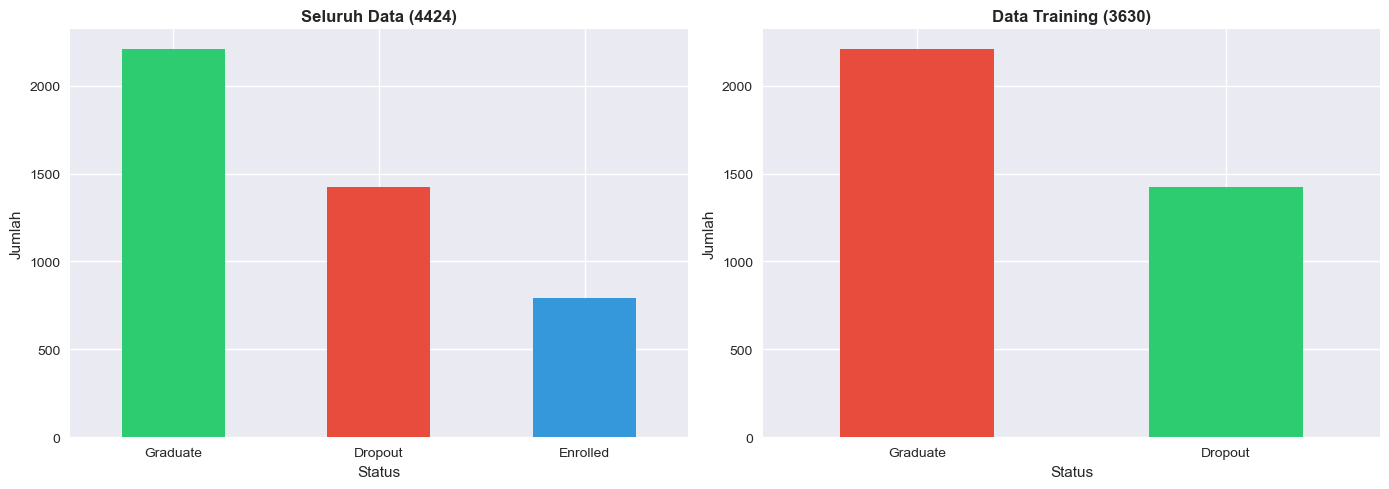

In [7]:
# Filter data: hanya Dropout dan Graduate untuk training
df_train = df[df['Status'].isin(['Dropout', 'Graduate'])].copy()

# Simpan data Enrolled untuk inferensi (opsional)
df_enrolled = df[df['Status'] == 'Enrolled'].copy()

print(f"Data untuk training: {len(df_train)} mahasiswa")
print(f"  - Dropout: {len(df_train[df_train['Status'] == 'Dropout'])}")
print(f"  - Graduate: {len(df_train[df_train['Status'] == 'Graduate'])}")
print(f"\nData Enrolled (untuk inferensi): {len(df_enrolled)} mahasiswa")

# Visualisasi distribusi data training
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sebelum filter
status_counts.plot(kind='bar', ax=axes[0], color=[colors[x] for x in status_counts.index])
axes[0].set_title('Seluruh Data (4424)', fontweight='bold')
axes[0].set_ylabel('Jumlah')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

# Sesudah filter
train_counts = df_train['Status'].value_counts()
train_counts.plot(kind='bar', ax=axes[1], color=['#e74c3c', '#2ecc71'])
axes[1].set_title(f'Data Training ({len(df_train)})', fontweight='bold')
axes[1].set_ylabel('Jumlah')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

In [8]:
features = [
    # Demografi
    'Marital_status', 'Gender', 'Age_at_enrollment', 'International',
    # Akademik
    'Admission_grade', 'Previous_qualification_grade',
    # Kurikulum Semester 1
    'Curricular_units_1st_sem_enrolled', 'Curricular_units_1st_sem_approved',
    'Curricular_units_1st_sem_grade',
    # Kurikulum Semester 2
    'Curricular_units_2nd_sem_enrolled', 'Curricular_units_2nd_sem_approved',
    'Curricular_units_2nd_sem_grade',
    # Finansial
    'Debtor', 'Tuition_fees_up_to_date', 'Scholarship_holder',
    # Ekonomi
    'Unemployment_rate', 'Inflation_rate', 'GDP'
]

target = 'Status'

# Gunakan df_train (hanya Dropout dan Graduate)
X = df_train[features]
y = df_train[target]

print(f"Jumlah fitur: {len(features)}")
print(f"Jumlah data training: {len(X)}")
print(f"\nFitur yang dipilih:")
for i, f in enumerate(features, 1):
    print(f"  {i}. {f}")

Jumlah fitur: 18
Jumlah data training: 3630

Fitur yang dipilih:
  1. Marital_status
  2. Gender
  3. Age_at_enrollment
  4. International
  5. Admission_grade
  6. Previous_qualification_grade
  7. Curricular_units_1st_sem_enrolled
  8. Curricular_units_1st_sem_approved
  9. Curricular_units_1st_sem_grade
  10. Curricular_units_2nd_sem_enrolled
  11. Curricular_units_2nd_sem_approved
  12. Curricular_units_2nd_sem_grade
  13. Debtor
  14. Tuition_fees_up_to_date
  15. Scholarship_holder
  16. Unemployment_rate
  17. Inflation_rate
  18. GDP


In [10]:
label_encoder_target = LabelEncoder()
y_encoded = label_encoder_target.fit_transform(y)

print("Label mapping (Binary Classification):")
for i, label in enumerate(label_encoder_target.classes_):
    print(f"  {label} -> {i}")

print(f"\nJumlah kelas: {len(label_encoder_target.classes_)}")
print(f"Distribusi: Dropout={sum(y == 'Dropout')}, Graduate={sum(y == 'Graduate')}")

Label mapping (Binary Classification):
  Dropout -> 0
  Graduate -> 1

Jumlah kelas: 2
Distribusi: Dropout=1421, Graduate=2209


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set:  {X_test.shape[0]} samples")
print(f"Split ratio:  80% train, 20% test")
print(f"\nDistribusi target training:")
print(f"  Dropout:  {sum(y_train == 0)}")
print(f"  Graduate: {sum(y_train == 1)}")

Training set: 2904 samples
Testing set:  726 samples
Split ratio:  80% train, 20% test

Distribusi target training:
  Dropout:  1137
  Graduate: 1767


In [13]:
scaler = StandardScaler()

numerical_cols = [
    'Age_at_enrollment', 'Admission_grade', 'Previous_qualification_grade',
    'Curricular_units_1st_sem_enrolled', 'Curricular_units_1st_sem_approved',
    'Curricular_units_1st_sem_grade', 'Curricular_units_2nd_sem_enrolled',
    'Curricular_units_2nd_sem_approved', 'Curricular_units_2nd_sem_grade',
    'Unemployment_rate', 'Inflation_rate', 'GDP'
]

X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

print(f"✅ Feature scaling selesai ({len(numerical_cols)} fitur numerik)")

✅ Feature scaling selesai (12 fitur numerik)


## Modeling

In [14]:
# MODEL 1: LOGISTIC REGRESSION (Binary Classification)
print("=" * 60)
print("MODEL 1: LOGISTIC REGRESSION")
print("Klasifikasi Binary: Dropout vs Graduate")
print("=" * 60)

lr_model = LogisticRegression(
    max_iter=2000,
    random_state=42,
    solver='lbfgs'
)
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)
y_prob_lr = lr_model.predict_proba(X_test)

accuracy_lr = accuracy_score(y_test, y_pred_lr)
print(f"\nAccuracy: {accuracy_lr:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_lr, target_names=label_encoder_target.classes_))

MODEL 1: LOGISTIC REGRESSION
Klasifikasi Binary: Dropout vs Graduate

Accuracy: 0.9201

Classification Report:
              precision    recall  f1-score   support

     Dropout       0.96      0.83      0.89       284
    Graduate       0.90      0.98      0.94       442

    accuracy                           0.92       726
   macro avg       0.93      0.90      0.91       726
weighted avg       0.92      0.92      0.92       726



In [15]:
# MODEL 2: RANDOM FOREST (Binary Classification)
print("=" * 60)
print("MODEL 2: RANDOM FOREST")
print("Klasifikasi Binary: Dropout vs Graduate")
print("=" * 60)

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"\nAccuracy: {accuracy_rf:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=label_encoder_target.classes_))

MODEL 2: RANDOM FOREST
Klasifikasi Binary: Dropout vs Graduate

Accuracy: 0.9077

Classification Report:
              precision    recall  f1-score   support

     Dropout       0.95      0.81      0.87       284
    Graduate       0.89      0.97      0.93       442

    accuracy                           0.91       726
   macro avg       0.92      0.89      0.90       726
weighted avg       0.91      0.91      0.91       726



## Evaluation

In [16]:
print("=" * 60)
print("PERBANDINGAN MODEL (Binary: Dropout vs Graduate)")
print("=" * 60)

print("\n+---------------------+----------------+----------------+")
print("| Metrik              | Logistic Reg   | Random Forest  |")
print("+---------------------+----------------+----------------+")
print(f"| Accuracy            | {accuracy_lr:>14.4f} | {accuracy_rf:>14.4f} |")
print("+---------------------+----------------+----------------+")

if accuracy_rf > accuracy_lr:
    print("\n=> Random Forest lebih baik!")
    best_model = rf_model
    best_model_name = "Random Forest"
else:
    print("\n=> Logistic Regression lebih baik!")
    best_model = lr_model
    best_model_name = "Logistic Regression"

PERBANDINGAN MODEL (Binary: Dropout vs Graduate)

+---------------------+----------------+----------------+
| Metrik              | Logistic Reg   | Random Forest  |
+---------------------+----------------+----------------+
| Accuracy            |         0.9201 |         0.9077 |
+---------------------+----------------+----------------+

=> Logistic Regression lebih baik!
